# the organization Phase 1.5 — Task-Level EDA & Clustering

**Purpose:** go beyond the 23-teammate KPI summary and work directly with the
**Raw Data** sheet (643 individual task rows) from
`the organization_-_Phase_1_KPI_Table_-_May_2026.xlsx`. This sheet has richer detail
that the summary table doesn't: every task's category, a free-text
description, and hours logged.

**What this notebook does:**
1. EDA on the 643 task rows — category distributions, hours by practice, a flagged-rate check
2. Clustering approach 1 — group **teammates** by how they split their time across task categories (a behavioral fingerprint, richer than the 7 KPI ratios used in Phase 1)
3. Clustering approach 2 — group **tasks** by the text of their descriptions, to see if natural themes emerge

**Not covered here:** this still can't test whether these patterns predict client
outcomes (CSAT, defects, escalations) — those columns are still blank pending
Capability Manager entry. This notebook is the EDA + clustering half only.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')

## 2. Upload the file
Run this cell in Colab and select
`the organization_-_Phase_1_KPI_Table_-_May_2026.xlsx` when prompted.
If you're running locally instead, skip this cell and just set `FILENAME`
to the path of the file on your machine.

In [8]:
try:
    from google.colab import files
    uploaded = files.upload()
    FILENAME = list(uploaded.keys())[0]
except ImportError:
    # Not running in Colab — set this manually
    FILENAME = "../data/MinoriLabs - Phase 1 KPI Table - May 2026.xlsx"

print("Using file:", FILENAME)

Using file: ../data/MinoriLabs - Phase 1 KPI Table - May 2026.xlsx


## 3. Load the Raw Data sheet

In [9]:
raw = pd.read_excel(FILENAME, sheet_name="Raw Data")
print("Shape:", raw.shape)
raw.head(10)

Shape: (643, 10)


,#,Capability Practice,Teammate ID,Client Code,Period,Task Category,Property,Task Description,Month Total (hrs),Flagged
0,1,Webtech,T-001,CLIENT-01,May 2026,Billable-Meetings,NaN,Internal Meetings,0.0,No
1,2,Webtech,T-001,CLIENT-01,May 2026,Billable-Production,NaN,Deployment - Credit amount updates for auto de...,0.0,No
2,3,Webtech,T-001,CLIENT-01,May 2026,Billable-Production,NaN,Additional logs to trace issues,0.0,No
3,4,Webtech,T-001,CLIENT-01,May 2026,Billable-Production,NaN,Retry Mechanism - Marketo,0.0,No
4,5,Webtech,T-001,CLIENT-01,May 2026,Billable-Meetings,NaN,Client Meeting,0.0,No
5,6,Webtech,T-002,CLIENT-01,May 2026,Billable-Production,NaN,CLIENT-01-Application monitoring,10.0,No
6,7,Webtech,T-002,CLIENT-01,May 2026,Billable-Meetings,NaN,Daily Huddle,10.0,No
7,8,Webtech,T-003,CLIENT-02,May 2026,Billable-Production,NaN,Ongoing Maintenance - DB clean up,10.0,No
8,9,Webtech,T-003,CLIENT-02,May 2026,Billable-Production,NaN,Ongoing Maintenance - Plugin updates,10.0,No
9,10,Webtech,T-003,CLIENT-02,May 2026,Billable-Production,NaN,CLIENT-02 DB Cleaner issue – analyzing and fixing,4.0,No


In [10]:
raw.info()
print()
print("Missing values per column:")
print(raw.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #                    643 non-null    int64  
 1   Capability Practice  643 non-null    str    
 2   Teammate ID          643 non-null    str    
 3   Client Code          643 non-null    str    
 4   Period               643 non-null    str    
 5   Task Category        643 non-null    str    
 6   Property             0 non-null      float64
 7   Task Description     643 non-null    str    
 8   Month Total (hrs)    643 non-null    float64
 9   Flagged              643 non-null    str    
dtypes: float64(2), int64(1), str(7)
memory usage: 101.5 KB

Missing values per column:
#                        0
Capability Practice      0
Teammate ID              0
Client Code              0
Period                   0
Task Category            0
Property               643
Task Description         0
Mo

`Property` is entirely empty — not a data issue, that column just isn't used
in this dataset. Every other field is fully populated across all 643 rows.

## 4. EDA — task categories, practices, and hours

Task Category
Billable-Production                   503
Billable-Meetings                      60
Billable-QC                            41
Billable-Requirement Understanding     13
Non Billable-Off                       10
Billable-Rework                         5
Billable-Reporting                      4
Others                                  4
Billable-Idle                           2
Non Billable-Learning                   1
Name: count, dtype: int64


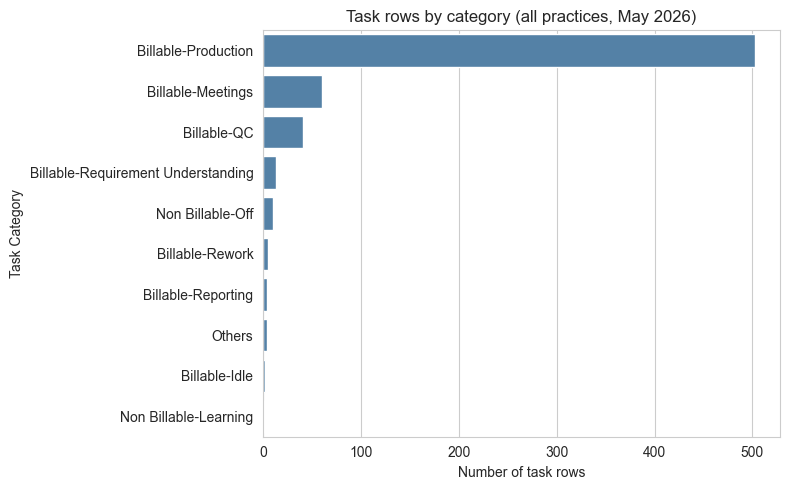

In [11]:
cat_counts = raw['Task Category'].value_counts()
print(cat_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, color='steelblue')
plt.xlabel('Number of task rows')
plt.title('Task rows by category (all practices, May 2026)')
plt.tight_layout()
plt.show()

Capability Practice
Webtech               240
Execution             155
Graphics              113
Data                   63
Content                41
Search Advertising     28
Calling Support         3
Name: count, dtype: int64


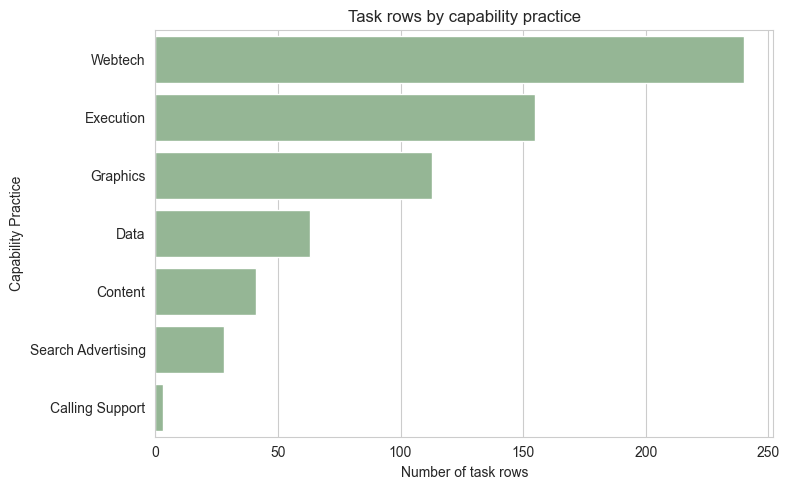

In [12]:
practice_counts = raw['Capability Practice'].value_counts()
print(practice_counts)

plt.figure(figsize=(8,5))
sns.barplot(x=practice_counts.values, y=practice_counts.index, color='darkseagreen')
plt.xlabel('Number of task rows')
plt.title('Task rows by capability practice')
plt.tight_layout()
plt.show()

### Time allocation heatmap
Total hours logged per capability practice x task category — this shows where
each practice's time actually goes (production vs. rework vs. meetings, etc.),
which the 7-ratio summary table couldn't show at this resolution.

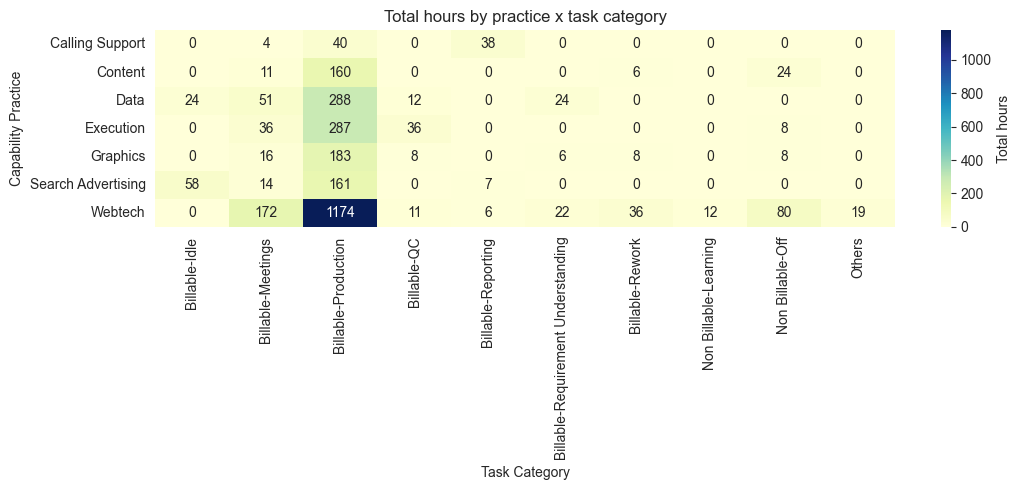

Task Category,Billable-Idle,Billable-Meetings,Billable-Production,Billable-QC,Billable-Reporting,Billable-Requirement Understanding,Billable-Rework,Non Billable-Learning,Non Billable-Off,Others
Capability Practice,,,,,,,,,,
Calling Support,0.0,4.00,40.0,0.0,38.5,0.0,0.0,0.0,0.0,0.0
Content,0.0,11.25,160.0,0.0,0.0,0.0,6.0,0.0,24.0,0.0
Data,24.0,51.00,287.5,11.5,0.0,23.5,0.0,0.0,0.0,0.0
Execution,0.0,36.50,287.0,36.5,0.0,0.0,0.0,0.0,8.0,0.0
Graphics,0.0,16.00,183.0,7.5,0.0,5.5,8.0,0.0,8.0,0.0
Search Advertising,57.5,14.50,161.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
Webtech,0.0,172.00,1174.0,11.0,6.0,21.5,36.5,12.0,80.0,19.0


In [13]:
hours_pivot = raw.pivot_table(
    index='Capability Practice', columns='Task Category',
    values='Month Total (hrs)', aggfunc='sum', fill_value=0
)

plt.figure(figsize=(11,5))
sns.heatmap(hours_pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Total hours'})
plt.title('Total hours by practice x task category')
plt.tight_layout()
plt.show()

hours_pivot

### Flagged rate by category
`Flagged` marks non-standardized task-category naming (a data-quality issue),
not a quality defect — worth checking whether flagging clusters in particular
categories, since that would point to where task-logging conventions are
least consistent.

Task Category
Others                                100.0%
Billable-Idle                           0.0%
Billable-Meetings                       0.0%
Billable-Production                     0.0%
Billable-QC                             0.0%
Billable-Reporting                      0.0%
Billable-Requirement Understanding      0.0%
Billable-Rework                         0.0%
Non Billable-Learning                   0.0%
Non Billable-Off                        0.0%
Name: Flagged, dtype: str


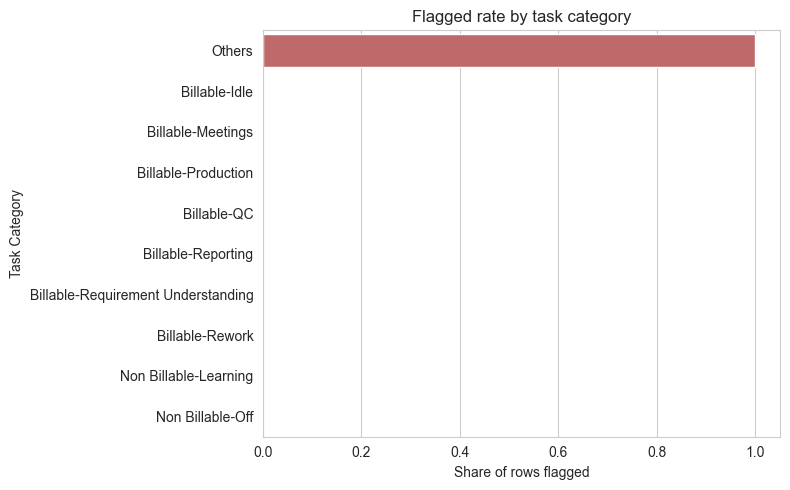

In [14]:
flag_rate = raw.groupby('Task Category')['Flagged'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
print((flag_rate * 100).round(1).astype(str) + '%')

plt.figure(figsize=(8,5))
sns.barplot(x=flag_rate.values, y=flag_rate.index, color='indianred')
plt.xlabel('Share of rows flagged')
plt.title('Flagged rate by task category')
plt.tight_layout()
plt.show()

### A data-quality note worth flagging in the project
`T-004` showed zero billable hours in the KPI Summary sheet and was excluded
from the Phase 1 correlation analysis. The cell below checks whether T-004
actually has task rows here in Raw Data — if so, that's the miscategorization
already noted in the Phase 1 log, visible directly in the underlying data.

In [15]:
t004 = raw[raw['Teammate ID'] == 'T-004']
print(f"T-004 has {len(t004)} task rows, {t004['Month Total (hrs)'].sum()} total hours logged")
t004[['Task Category', 'Task Description', 'Month Total (hrs)', 'Flagged']]

T-004 has 4 task rows, 19.0 total hours logged


,Task Category,Task Description,Month Total (hrs),Flagged
37,Others,CLIENT-03 spam issue fixing,1.0,Yes
38,Others,CLIENT-03 spam issue fully analysing and find ...,7.0,Yes
39,Others,Analysis the issue on image update and provide...,4.0,Yes
40,Others,slider button issue fixing in mobile and deskt...,7.0,Yes


## 5. Clustering approach 1 — teammates by time-allocation profile

Instead of the 7 KPI ratios used in Phase 1, this builds a richer feature per
teammate: **what % of their total hours went to each of the 10 task
categories.** This is a fuller behavioral fingerprint than the ratio table
alone, and it's built straight from the same Raw Data.

Teammates with zero total hours (no real activity to compute a percentage
from) are excluded and listed below.

In [16]:
pivot = raw.pivot_table(
    index='Teammate ID', columns='Task Category',
    values='Month Total (hrs)', aggfunc='sum', fill_value=0
)

row_sums = pivot.sum(axis=1)
excluded = row_sums[row_sums == 0].index.tolist()
print(f"Excluding {len(excluded)} teammate(s) with zero total hours: {excluded}")

pivot = pivot.loc[row_sums > 0]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

print(f"\nClustering on {pivot_pct.shape[0]} teammates x {pivot_pct.shape[1]} category-share features")
pivot_pct.round(2).head()

Excluding 1 teammate(s) with zero total hours: ['T-001']

Clustering on 22 teammates x 10 category-share features


Task Category,Billable-Idle,Billable-Meetings,Billable-Production,Billable-QC,Billable-Reporting,Billable-Requirement Understanding,Billable-Rework,Non Billable-Learning,Non Billable-Off,Others
Teammate ID,,,,,,,,,,
T-002,0.0,0.50,0.50,0.00,0.00,0.00,0.0,0.00,0.00,0.0
T-003,0.0,0.08,0.72,0.06,0.02,0.00,0.0,0.07,0.05,0.0
T-004,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,1.0
T-005,0.0,0.09,0.79,0.05,0.00,0.08,0.0,0.00,0.00,0.0
T-006,0.0,0.06,0.89,0.00,0.04,0.00,0.0,0.00,0.00,0.0


### Picking k — elbow and silhouette score
With only ~22 teammates, don't expect a clean elbow. The silhouette score
often favors a very low k here — that's expected with a small, unevenly
distributed sample, and usually means k-means is isolating one or two
outliers rather than finding balanced behavioral groups. Check the cluster
sizes printed below before trusting a "good" silhouette score at face value.

k=2  inertia=178.89  silhouette=0.459
k=3  inertia=144.12  silhouette=0.364
k=4  inertia=112.32  silhouette=0.389
k=5  inertia=88.71  silhouette=0.400
k=6  inertia=64.68  silhouette=0.413


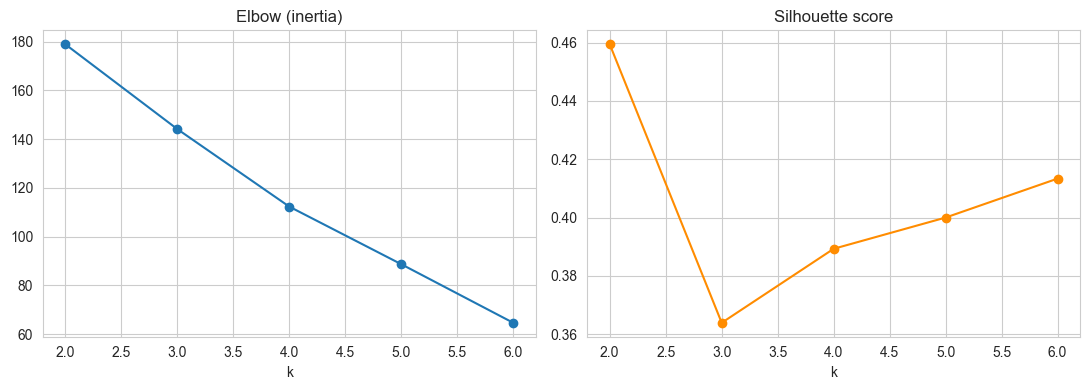

In [17]:
X = StandardScaler().fit_transform(pivot_pct.values)

scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sil = silhouette_score(X, km.labels_)
    scores.append((k, km.inertia_, sil))
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={sil:.3f}")

ks, inertias, sils = zip(*scores)
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(ks, inertias, marker='o'); axes[0].set_title('Elbow (inertia)'); axes[0].set_xlabel('k')
axes[1].plot(ks, sils, marker='o', color='darkorange'); axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

In [18]:
K_TEAMMATES = 3  # adjust based on the plot above and cluster-size sanity check

km_team = KMeans(n_clusters=K_TEAMMATES, n_init=10, random_state=42).fit(X)
pivot_pct_labeled = pivot_pct.copy()
pivot_pct_labeled['cluster'] = km_team.labels_

print("Cluster sizes:")
print(pivot_pct_labeled['cluster'].value_counts().sort_index())
print()
print("Mean category-share profile per cluster (interpret these as archetypes):")
pivot_pct_labeled.groupby('cluster').mean().round(2)

Cluster sizes:
cluster
0    19
1     1
2     2
Name: count, dtype: int64

Mean category-share profile per cluster (interpret these as archetypes):


Task Category,Billable-Idle,Billable-Meetings,Billable-Production,Billable-QC,Billable-Reporting,Billable-Requirement Understanding,Billable-Rework,Non Billable-Learning,Non Billable-Off,Others
cluster,,,,,,,,,,
0,0.00,0.11,0.75,0.02,0.03,0.01,0.00,0.0,0.03,0.05
1,0.00,0.11,0.38,0.00,0.00,0.13,0.22,0.0,0.15,0.00
2,0.66,0.12,0.14,0.04,0.00,0.05,0.00,0.0,0.00,0.00


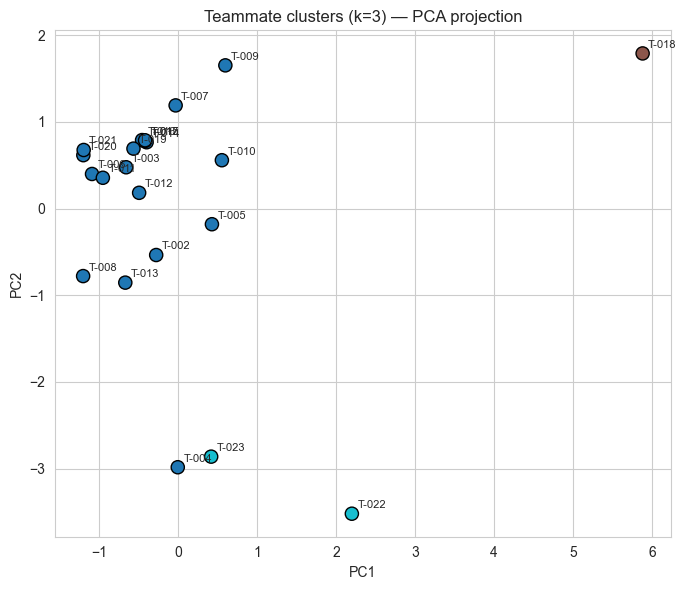

In [19]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(7,6))
scatter = plt.scatter(coords[:,0], coords[:,1], c=km_team.labels_, cmap='tab10', s=90, edgecolor='k')
for i, tid in enumerate(pivot_pct.index):
    plt.annotate(tid, (coords[i,0], coords[i,1]), fontsize=8, xytext=(4,4), textcoords='offset points')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'Teammate clusters (k={K_TEAMMATES}) — PCA projection')
plt.tight_layout()
plt.show()

**Worth cross-checking:** the Phase 1 anomaly detection already flagged
T-006, T-015, T-020, and T-023 as task-concentration anomalies using a
different method (3x-own-average rule). If those same teammates land in a
small, separated cluster here, that's two independent methods agreeing —
worth a line in your findings section either way.

In [20]:
anomaly_ids = ['T-006', 'T-015', 'T-020', 'T-023']
overlap = pivot_pct_labeled.loc[pivot_pct_labeled.index.intersection(anomaly_ids), 'cluster']
print("Cluster assignment for previously-flagged anomaly teammates:")
print(overlap)

Cluster assignment for previously-flagged anomaly teammates:
Teammate ID
T-006    0
T-015    0
T-020    0
T-023    2
Name: cluster, dtype: int32


## 6. Clustering approach 2 — tasks by description text

This clusters the 643 `Task Description` strings using TF-IDF (term
frequency, weighted down for common words) + k-means, to see whether natural
task themes emerge on their own — independent of the existing Task Category
labels.

**Caveat going in:** these descriptions are short and factual ("QC comparing
live site and staging site"), not expressive text — this is topic-style
clustering, not sentiment analysis. Expect modest silhouette scores; the
value here is in the top terms per cluster, not the score itself.

In [21]:
text = raw['Task Description'].fillna('').astype(str)

tfidf = TfidfVectorizer(max_features=150, stop_words='english', ngram_range=(1,2), min_df=3)
X_text = tfidf.fit_transform(text)
print("TF-IDF matrix shape:", X_text.shape)

for k in [4, 6, 8, 10]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_text)
    sil = silhouette_score(X_text, km.labels_)
    print(f"k={k}  silhouette={sil:.3f}")

TF-IDF matrix shape: (643, 150)
k=4  silhouette=0.067
k=6  silhouette=0.077
k=8  silhouette=0.096
k=10  silhouette=0.123


In [22]:
K_TEXT = 6  # chosen from the scan above — adjust if a different k reads more coherently

km_text = KMeans(n_clusters=K_TEXT, n_init=10, random_state=42).fit(X_text)
raw['text_cluster'] = km_text.labels_

terms = tfidf.get_feature_names_out()
order_centroids = km_text.cluster_centers_.argsort()[:, ::-1]

for i in range(K_TEXT):
    top_terms = [terms[ind] for ind in order_centroids[i, :8]]
    n = (km_text.labels_ == i).sum()
    print(f"Cluster {i} (n={n}): {', '.join(top_terms)}")

Cluster 0 (n=341): issue, analysis, ids, vc, lp, issue analysis, internal, leave
Cluster 1 (n=67): blog, updates, ids, smart, vc, publish, blog 2026, smart cooler
Cluster 2 (n=24): wrap, wrap min, min, graphics, combo, gif, huddle, header
Cluster 3 (n=88): ev, page, vcom, optimization, content, content optimization, updates, analysis
Cluster 4 (n=74): update, client, client 02, 02, client meeting, meeting, theme, menu
Cluster 5 (n=49): min, banner, blog banner, ev, email, update, week, spectra


### Cross-check against the existing Task Category labels
If a text cluster lines up neatly with one Task Category, the text clustering
mostly just rediscovered a label you already had. If a text cluster cuts
*across* categories, that's more interesting — it means tasks logged under
different categories actually describe similar underlying work.

In [23]:
cross = pd.crosstab(raw['text_cluster'], raw['Task Category'])
cross

Task Category,Billable-Idle,Billable-Meetings,Billable-Production,Billable-QC,Billable-Reporting,Billable-Requirement Understanding,Billable-Rework,Non Billable-Learning,Non Billable-Off,Others
text_cluster,,,,,,,,,,
0,2,43,252,17,2,8,5,1,10,1
1,0,1,59,7,0,0,0,0,0,0
2,0,0,20,4,0,0,0,0,0,0
3,0,2,77,8,0,1,0,0,0,0
4,0,14,51,4,2,0,0,0,0,3
5,0,0,44,1,0,4,0,0,0,0


## 7. Caveats — read before writing these up

- **Single-month snapshot.** All 643 rows are from May 2026 only — there's no
  time dimension here, so nothing in this notebook shows change over time.
- **Small n for teammate clustering** (~22 people). Treat cluster assignments
  as exploratory and worth a human sanity-check, not statistically confirmed
  segments.
- **Text clustering silhouette scores are modest** (typically 0.05–0.15).
  That's expected for short, formulaic task descriptions — read the top-terms
  output qualitatively rather than treating the score as a quality bar to
  clear.
- **`Flagged` is a data-quality flag, not a defect flag** — carried over from
  the Phase 1 log, still true here.
- **This does not test the core project hypoproject** (does behavior predict
  client outcomes). That still needs the CM-entered CSAT/Defects/Escalations/
  KPI Achievement columns.

## 8. Export results

In [24]:
pivot_pct_labeled.to_csv('teammate_time_allocation_clusters.csv')
raw.to_csv('task_level_with_text_clusters.csv', index=False)

print("Saved: teammate_time_allocation_clusters.csv")
print("Saved: task_level_with_text_clusters.csv")

try:
    from google.colab import files as colab_files
    colab_files.download('teammate_time_allocation_clusters.csv')
    colab_files.download('task_level_with_text_clusters.csv')
except ImportError:
    pass

Saved: teammate_time_allocation_clusters.csv
Saved: task_level_with_text_clusters.csv


## 9. Next steps

- Bring the teammate cluster profiles and the anomaly cross-check into your
  Phase 1 findings section as a second, independent method pointing at the
  same individuals.
- Once CM data lands, test whether cluster membership (from section 5)
  correlates with CSAT/escalations — this turns exploratory clustering into
  an actual predictor.
- If a text cluster from section 6 looks meaningful (e.g. a "client meeting"
  or "content/blog" cluster), it's a candidate feature for the Random
  Forest step later — a binary flag for "this task belongs to cluster X".